In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os

warnings.filterwarnings("ignore")

sys.path.append(os.path.join(os.path.dirname("__file__"), "..", "src"))

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
RAW_DATA_PATH = "../data/raw/telco_churn_raw.csv"

df_raw = pd.read_csv(RAW_DATA_PATH)

print(f"Shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
df_raw.head()

Shape: (7043, 21)
Rows: 7,043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
COLUMN_MAPPING = {
    "customerID":       "customer_id",
    "gender":           "gender",
    "SeniorCitizen":    "is_senior",
    "Partner":          "has_partner",
    "Dependents":       "has_dependents",
    "tenure":           "months_as_customer",
    "PhoneService":     "has_phone_service",
    "MultipleLines":    "has_multiple_lines",
    "InternetService":  "primary_product",
    "OnlineSecurity":   "has_security_product",
    "OnlineBackup":     "has_backup_product",
    "DeviceProtection": "has_protection_plan",
    "TechSupport":      "has_support_plan",
    "StreamingTV":      "has_streaming_tv",
    "StreamingMovies":  "has_streaming_movies",
    "Contract":         "account_type",
    "PaperlessBilling": "is_paperless",
    "PaymentMethod":    "payment_method",
    "MonthlyCharges":   "monthly_transaction_volume",
    "TotalCharges":     "total_transaction_volume",
    "Churn":            "churned"
}

df = df_raw.rename(columns=COLUMN_MAPPING).copy()

print("Columns renamed successfully")
print(df.columns.tolist())

Columns renamed successfully
['customer_id', 'gender', 'is_senior', 'has_partner', 'has_dependents', 'months_as_customer', 'has_phone_service', 'has_multiple_lines', 'primary_product', 'has_security_product', 'has_backup_product', 'has_protection_plan', 'has_support_plan', 'has_streaming_tv', 'has_streaming_movies', 'account_type', 'is_paperless', 'payment_method', 'monthly_transaction_volume', 'total_transaction_volume', 'churned']


In [7]:
print("=== SCHEMA AUDIT ===")
print(df.dtypes)
print()

print("=== NULL VALUES ===")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No nulls detected at surface level")
print()

print("=== UNIQUE VALUE COUNTS ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

=== SCHEMA AUDIT ===
customer_id                    object
gender                         object
is_senior                       int64
has_partner                    object
has_dependents                 object
months_as_customer              int64
has_phone_service              object
has_multiple_lines             object
primary_product                object
has_security_product           object
has_backup_product             object
has_protection_plan            object
has_support_plan               object
has_streaming_tv               object
has_streaming_movies           object
account_type                   object
is_paperless                   object
payment_method                 object
monthly_transaction_volume    float64
total_transaction_volume       object
churned                        object
dtype: object

=== NULL VALUES ===
No nulls detected at surface level

=== UNIQUE VALUE COUNTS ===
customer_id: 7043 unique values
gender: 2 unique values
is_senior: 2 unique values

In [ ]:
df["total_transaction_volume"] = pd.to_numeric(
    df["total_transaction_volume"], errors="coerce"
)

missing_total = df["total_transaction_volume"].isnull().sum()
print(f"Missing total_transaction_volume after conversion: {missing_total}")

print(df[df["total_transaction_volume"].isnull()][
    ["customer_id", "months_as_customer", "monthly_transaction_volume", "total_transaction_volume"]
])

Missing total_transaction_volume after conversion: 11
     customer_id  months_as_customer  monthly_transaction_volume  \
488   4472-LVYGI                   0                       52.55   
753   3115-CZMZD                   0                       20.25   
936   5709-LVOEQ                   0                       80.85   
1082  4367-NUYAO                   0                       25.75   
1340  1371-DWPAZ                   0                       56.05   
3331  7644-OMVMY                   0                       19.85   
3826  3213-VVOLG                   0                       25.35   
4380  2520-SGTTA                   0                       20.00   
5218  2923-ARZLG                   0                       19.70   
6670  4075-WKNIU                   0                       73.35   
6754  2775-SEFEE                   0                       61.90   

      total_transaction_volume  
488                        NaN  
753                        NaN  
936                        NaN

=== CHURN DISTRIBUTION ===
churned
No     5174
Yes    1869
Name: count, dtype: int64

=== CHURN RATE ===
churned
No     73.46
Yes    26.54
Name: proportion, dtype: float64


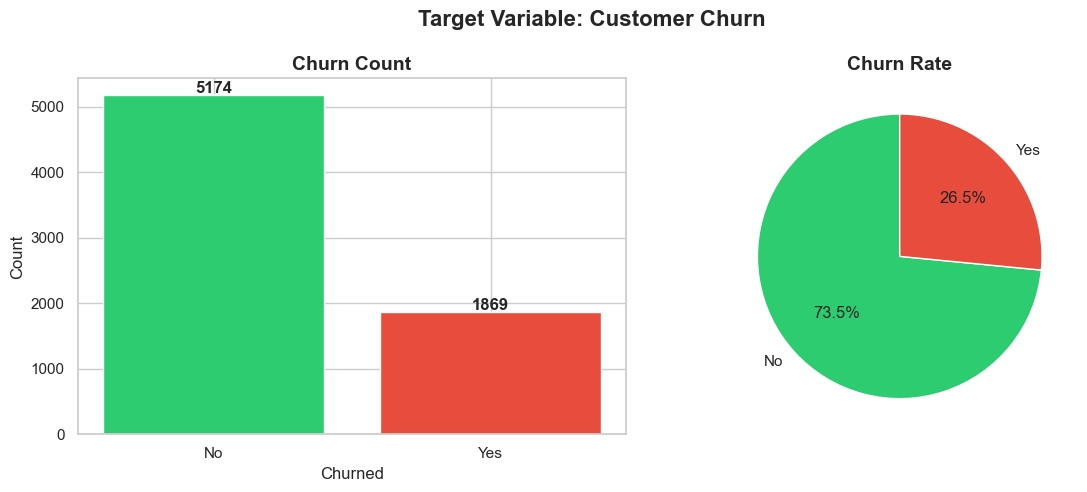


Business insight: ~26% churn rate — significant class imbalance. Will require strategic handling.


In [ ]:
churn_counts = df["churned"].value_counts()
churn_rate = df["churned"].value_counts(normalize=True) * 100

print("=== CHURN DISTRIBUTION ===")
print(churn_counts)
print()
print("=== CHURN RATE ===")
print(churn_rate.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(churn_counts.index, churn_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Count", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Churned")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(
    churn_rate.values,
    labels=churn_rate.index,
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90
)
axes[1].set_title("Churn Rate", fontsize=14, fontweight="bold")

plt.suptitle("Target Variable: Customer Churn", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/01_churn_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nBusiness insight: ~26% churn rate — significant class imbalance. Will require strategic handling.")

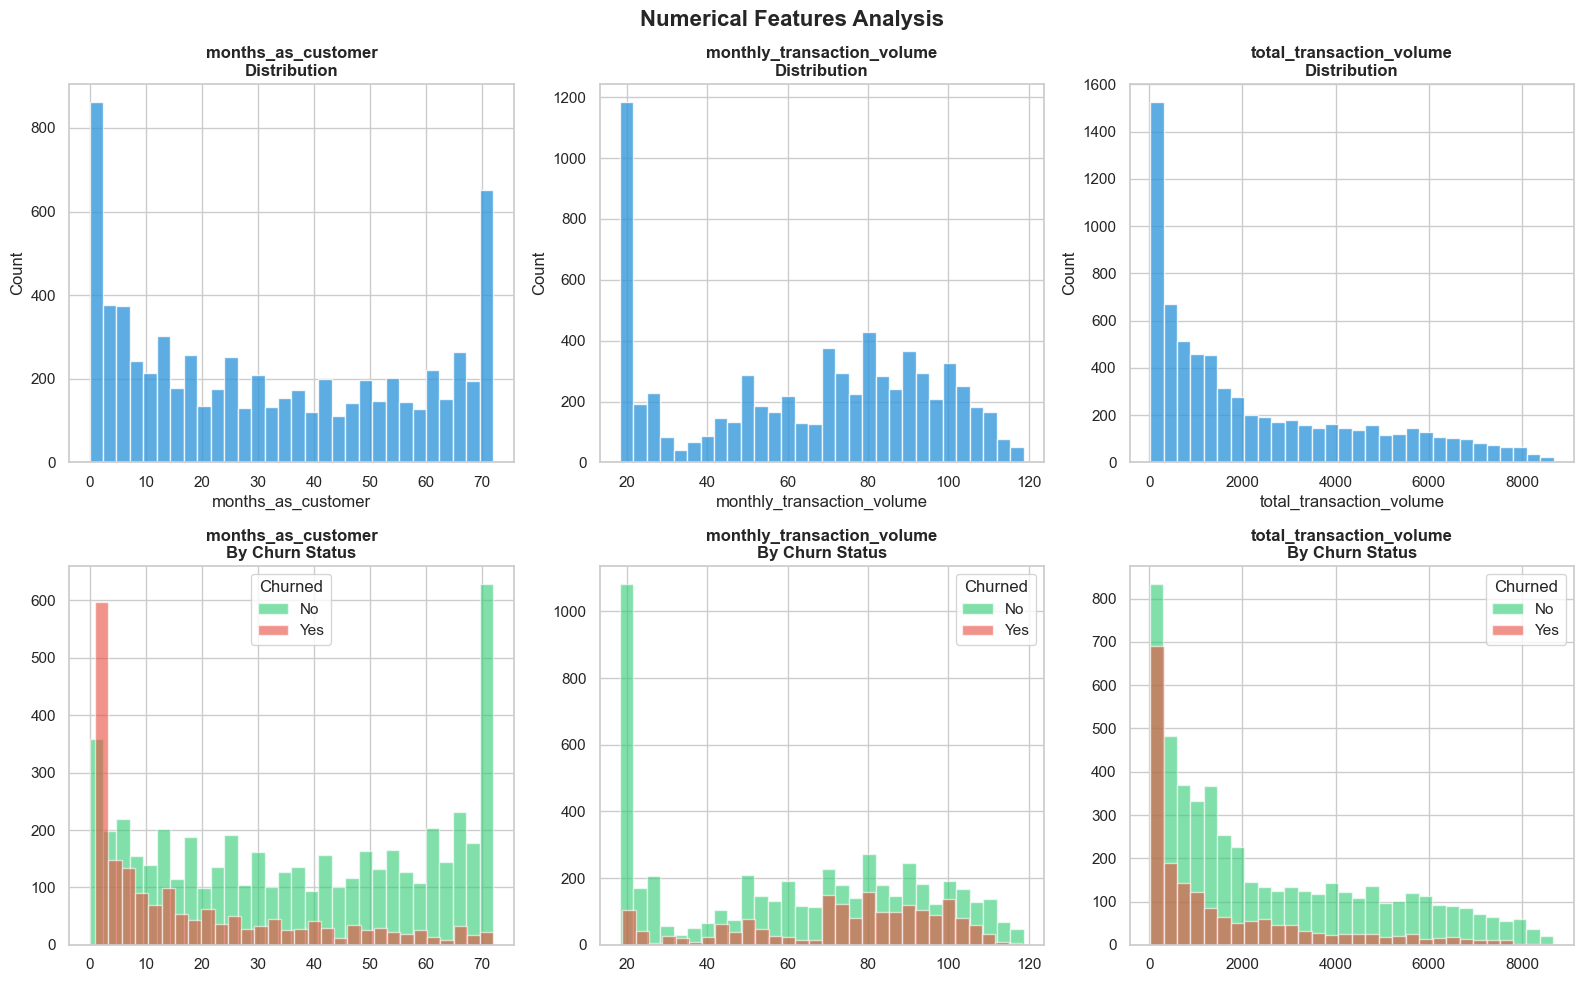

In [ ]:
numerical_cols = ["months_as_customer", "monthly_transaction_volume", "total_transaction_volume"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(numerical_cols):
    axes[0, i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(f"{col}\nDistribution", fontweight="bold")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Count")


    for label, color in zip(["No", "Yes"], ["#2ecc71", "#e74c3c"]):
        subset = df[df["churned"] == label][col].dropna()
        axes[1, i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="white")
    axes[1, i].set_title(f"{col}\nBy Churn Status", fontweight="bold")
    axes[1, i].legend(title="Churned")

plt.suptitle("Numerical Features Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/02_numerical_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

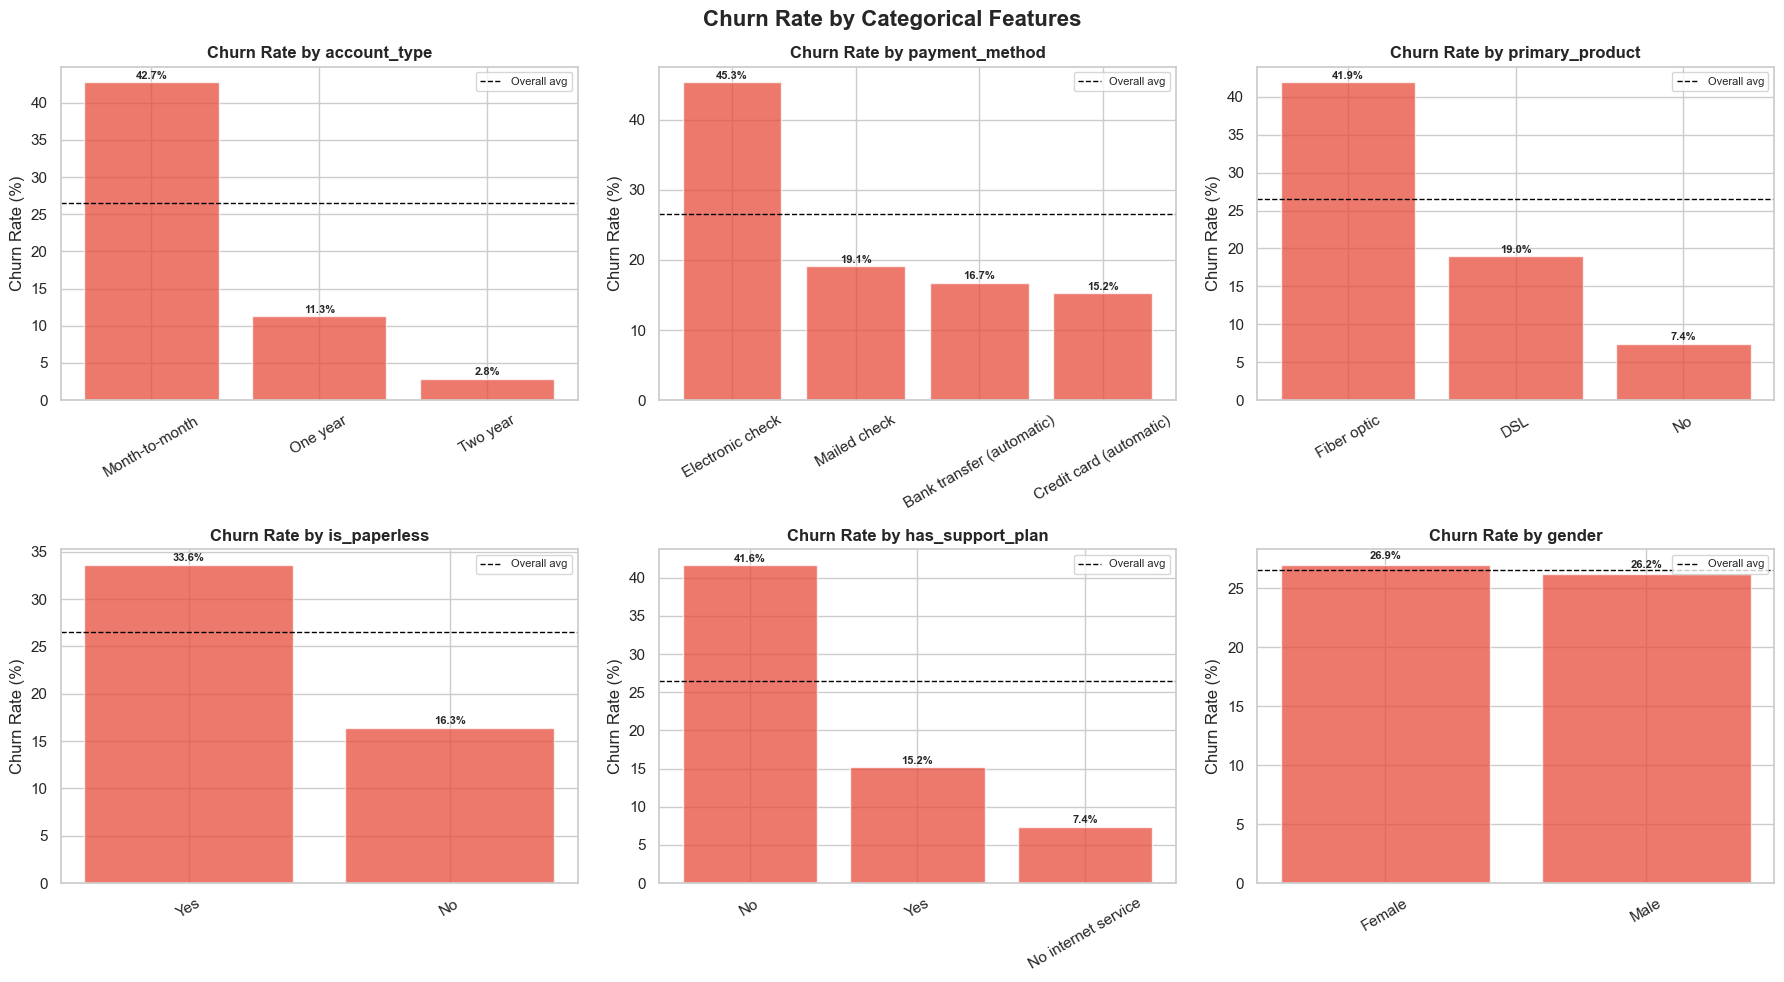

In [11]:
categorical_cols = [
    "account_type", "payment_method", "primary_product",
    "is_paperless", "has_support_plan", "gender"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_by_cat = (
        df.groupby(col)["churned"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .reset_index()
    )
    churn_by_cat.columns = [col, "churn_rate"]

    bars = axes[i].bar(
        churn_by_cat[col],
        churn_by_cat["churn_rate"],
        color="#e74c3c",
        alpha=0.75,
        edgecolor="white"
    )
    axes[i].set_title(f"Churn Rate by {col}", fontweight="bold")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].axhline(y=df["churned"].eq("Yes").mean() * 100,
                    color="black", linestyle="--", linewidth=1, label="Overall avg")
    axes[i].legend(fontsize=8)

    for bar, val in zip(bars, churn_by_cat["churn_rate"]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Churn Rate by Categorical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/03_churn_by_category.png", bbox_inches="tight", dpi=150)
plt.show()

In [12]:
insights = """
=== BUSINESS INSIGHTS FROM EDA ===

1. CLASS IMBALANCE: ~26% churn rate. Models trained without imbalance handling
   will predict 'No churn' for everyone and achieve 74% accuracy — which is useless.
   We will use scale_pos_weight in XGBoost and evaluate with ROC-AUC and F1.

2. CONTRACT TYPE IS THE STRONGEST SIGNAL: Month-to-month customers churn at ~43%
   vs ~3% for 2-year contracts. This is the most actionable business lever.

3. TENURE EFFECT: Customers who churn have significantly lower tenure.
   Early lifecycle intervention is critical — first 12 months are highest risk.

4. PAYMENT METHOD MATTERS: Electronic check users churn at ~45%.
   Customers on automatic payment churn at ~15-18%. Friction in payment = churn risk.

5. TOTAL CHARGES DATA QUALITY: 11 rows had missing total_transaction_volume
   due to string-to-numeric conversion. These are new customers (tenure=0).
   Imputation strategy: fill with monthly_transaction_volume (single month customers).
"""
print(insights)


=== BUSINESS INSIGHTS FROM EDA ===

1. CLASS IMBALANCE: ~26% churn rate. Models trained without imbalance handling
   will predict 'No churn' for everyone and achieve 74% accuracy — which is useless.
   We will use scale_pos_weight in XGBoost and evaluate with ROC-AUC and F1.

2. CONTRACT TYPE IS THE STRONGEST SIGNAL: Month-to-month customers churn at ~43%
   vs ~3% for 2-year contracts. This is the most actionable business lever.

3. TENURE EFFECT: Customers who churn have significantly lower tenure.
   Early lifecycle intervention is critical — first 12 months are highest risk.

4. PAYMENT METHOD MATTERS: Electronic check users churn at ~45%.
   Customers on automatic payment churn at ~15-18%. Friction in payment = churn risk.

5. TOTAL CHARGES DATA QUALITY: 11 rows had missing total_transaction_volume
   due to string-to-numeric conversion. These are new customers (tenure=0).
   Imputation strategy: fill with monthly_transaction_volume (single month customers).



In [13]:
PROCESSED_PATH = "../data/processed/churn_fintech_renamed.csv"
df.to_csv(PROCESSED_PATH, index=False)
print(f"Dataset saved to {PROCESSED_PATH}")
print(f"Shape: {df.shape}")

Dataset saved to ../data/processed/churn_fintech_renamed.csv
Shape: (7043, 21)
